# サンプリング定理とエイリアシング

このノートはサンプリング定理 (Shannon-Nyquist) の観点からエイリアシングがどのように現れるかを確認するためのデモです。
十分に細かくサンプリングした連続時間信号と、ナイキスト周波数を下回るサンプリング周波数によって発生する折り返し (alias) を比較します。


## サンプリング定理の復習

- サンプリング周波数 $f_s$ は信号に含まれる最高周波数 $f_{max}$ の 2 倍以上である必要があります。
- 条件を満たさない場合、離散時間信号は別の低い周波数成分に見えてしまい、これをエイリアシングと呼びます。

下のセルではこの現象をシンプルなサイン波で再現します。


In [280]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
import urllib.request

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

font_candidates = [
    'Noto Sans CJK JP', 'Noto Sans JP', 'IPAexGothic', 'Yu Gothic',
    'Meiryo', 'Hiragino Sans', 'MS Gothic', 'TakaoPGothic'
]
font_dir = Path('Aliasing/fonts') if Path('Aliasing').exists() else Path('fonts')
font_dir.mkdir(exist_ok=True)
font_path = font_dir / 'NotoSansCJKjp-Regular.otf'
font_url = 'https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/Japanese/NotoSansCJKjp-Regular.otf'
if not font_path.exists():
    try:
        urllib.request.urlretrieve(font_url, font_path)
        print('Noto Sans CJK JP をダウンロードしました。')
    except Exception as exc:
        print(f'フォントのダウンロードに失敗しました: {exc}')

if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'
else:
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    for font_name in font_candidates:
        if font_name in available_fonts:
            plt.rcParams['font.family'] = font_name
            print(f'使用フォント: {font_name}')
            break
    else:
        plt.rcParams['font.family'] = plt.rcParamsDefault['font.family']
        print('日本語フォントが見つからないため、既定フォントを使用しています。')

plt.rcParams['axes.unicode_minus'] = False


### シミュレーション用ユーティリティ
信号周波数 `f_signal`、サンプリング周波数 `f_s`、観測時間 `duration` を指定すると、滑らかな連続波形と離散サンプル列を返す関数です。


In [281]:
def simulate_signal(f_signal, fs, duration=5e-3, oversample=120):
    t_cont = np.linspace(0, duration, int(duration * fs * oversample), endpoint=False)
    x_cont = np.sin(2 * np.pi * f_signal * t_cont)
    t_sample = np.arange(0, duration, 1 / fs)
    x_sample = np.sin(2 * np.pi * f_signal * t_sample)
    return t_cont, x_cont, t_sample, x_sample

def alias_frequency(f_signal, fs):
    return abs(f_signal - np.round(f_signal / fs) * fs)


## 例: 1200 Hz のサイン波を 1 kHz でサンプリング
元のアナログ信号は $1200\,\mathrm{Hz}$ ですが、サンプリング周波数は $f_s = 1000\,\mathrm{Hz}$ しかないためナイキスト周波数 $f_s/2 = 500\,\mathrm{Hz}$ を満たしません。


#### グラフ: 1200 Hz 信号と 1 kHz サンプリングの比較
これからの図では、連続時間の波形と 1 kHz で取得したサンプル列を重ねて、折り返しが発生する条件を視覚的に確認します。


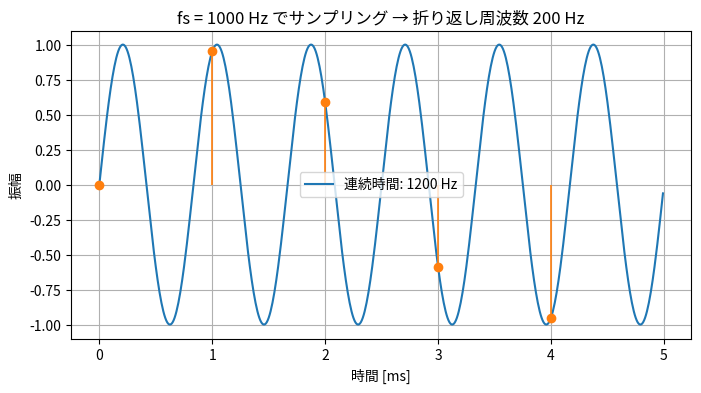

In [282]:
f_signal = 1200  # Hz
fs = 1000        # Hz
duration = 5e-3  # 秒

t_cont, x_cont, t_sample, x_sample = simulate_signal(f_signal, fs, duration)
f_alias = alias_frequency(f_signal, fs)

fig, ax = plt.subplots()
ax.plot(t_cont * 1e3, x_cont, label=f'連続時間: {f_signal} Hz')
markerline, stemlines, baseline = ax.stem(t_sample * 1e3, x_sample, linefmt='C1-', markerfmt='C1o', basefmt=' ')
plt.setp(stemlines, linewidth=1.2)
ax.set_xlabel('時間 [ms]')
ax.set_ylabel('振幅')
ax.set_title(f'fs = {fs} Hz でサンプリング → 折り返し周波数 {f_alias:.0f} Hz')
ax.legend()
plt.show()


サンプル列は $200\,\mathrm{Hz}$ のサイン波と完全に同じ並びになるため、スペクトル上では $200\,\mathrm{Hz}$ 成分として観測されます。これがエイリアシング（折り返し）の実体です。


#### グラフ: 200 Hz の折り返し成分との重ね合わせ
次の図ではサンプリング結果が 200 Hz の低周波と区別できないことを示し、エイリアスの実体を直感的につかめるようにしています。


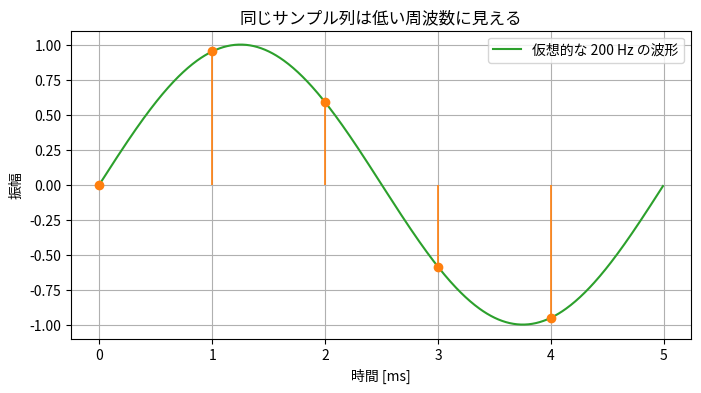

In [283]:
alias_wave = np.sin(2 * np.pi * f_alias * t_cont)

fig, ax = plt.subplots()
ax.plot(t_cont * 1e3, alias_wave, label=f'仮想的な {f_alias:.0f} Hz の波形', color='C2')
markerline, stemlines, baseline = ax.stem(t_sample * 1e3, x_sample, linefmt='C1-', markerfmt='C1o', basefmt=' ')
plt.setp(stemlines, linewidth=1.2)
ax.set_xlabel('時間 [ms]')
ax.set_ylabel('振幅')
ax.set_title('同じサンプル列は低い周波数に見える')
ax.legend()
plt.show()


オレンジ色の 200 Hz 波形と青色の 1200 Hz 波形はサンプル点では区別できません。そのため、復元時には 200 Hz の成分だと誤認してしまいます。


## ナイキスト条件を満たす場合
次に同じ信号を $f_s = 4000\,\mathrm{Hz}$ でサンプリングし、折り返しが発生しないケースを確認します。


#### グラフ: 十分なサンプリング周波数での波形
以下のグラフでは 4 kHz でサンプリングした際の連続波形とサンプル点を比較し、ナイキスト条件を満たすと折り返しが消える様子を示します。


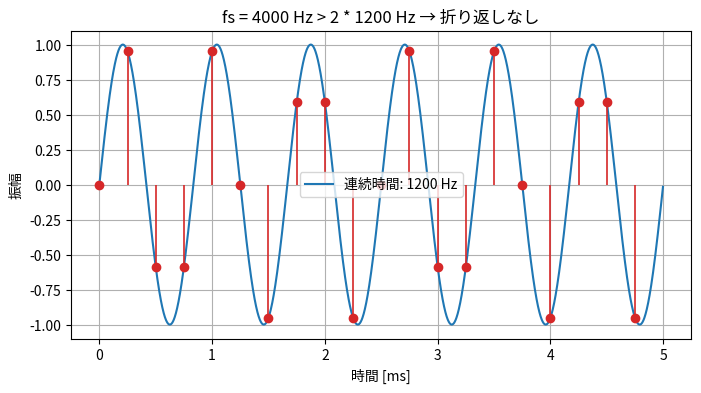

In [284]:
fs_safe = 4000
t_cont_safe, x_cont_safe, t_sample_safe, x_sample_safe = simulate_signal(f_signal, fs_safe, duration)

fig, ax = plt.subplots()
ax.plot(t_cont_safe * 1e3, x_cont_safe, label=f'連続時間: {f_signal} Hz')
markerline, stemlines, baseline = ax.stem(t_sample_safe * 1e3, x_sample_safe, linefmt='C3-', markerfmt='C3o', basefmt=' ')
plt.setp(stemlines, linewidth=1.2)
ax.set_xlabel('時間 [ms]')
ax.set_ylabel('振幅')
ax.set_title('fs = 4000 Hz > 2 * 1200 Hz → 折り返しなし')
ax.legend()
plt.show()


サンプリング周波数が十分に高いとサンプル点でも元の波形が忠実に追従していることが分かります。

パラメータ `f_signal` や `fs` を変更して、どの周波数で折り返しが発生するか試してみてください。例えば `f_signal = 1800` や `fs = 1500` などに書き換えると、折り返し周波数がどのように変わるかを確認できます。


## 周波数空間での確認
時間波形だけでなく、サンプル列の離散フーリエ変換 (DFT) を用いるとエイリアシングが周波数軸でどのように現れるかを視覚化できます。
ナイキストを満たさない場合は高周波成分が折り返して低周波のピークとして観測されます。


### FFT 用ユーティリティ
サンプル数が少ないと周波数分解能が粗くなるため、ゼロ詰め (zero padding) で補間したスペクトルを描画します。


In [285]:
def compute_spectrum(x_sample, fs, zero_pad=8):
    n = len(x_sample) * zero_pad
    X = np.fft.fft(x_sample, n=n)
    freqs = np.fft.fftfreq(n, d=1 / fs)
    pos = freqs >= 0
    scale = 2 / len(x_sample)
    return freqs[pos], np.abs(X[pos]) * scale

def plot_discrete_spectrum(freqs, magnitude, fs, ax=None, title='離散スペクトル'):
    if ax is None:
        fig, ax = plt.subplots()
    ax.stem(freqs, magnitude, linefmt='C4-', markerfmt='C4o', basefmt=' ')
    ax.set_xlim(0, fs / 2)
    ax.set_xlabel('周波数 [Hz]')
    ax.set_ylabel('振幅 (正規化)')
    ax.set_title(title)
    return ax


### 1 kHz で 1200 Hz をサンプリングしたときのスペクトル
離散スペクトル上では 1200 Hz のピークが 200 Hz に折り返して観測されることが分かります。


#### グラフ: 折り返しが起きた周波数スペクトル
このスペクトル図では 1 kHz サンプリングの結果、1200 Hz 成分が 200 Hz に折り返して観測されることを見せています。


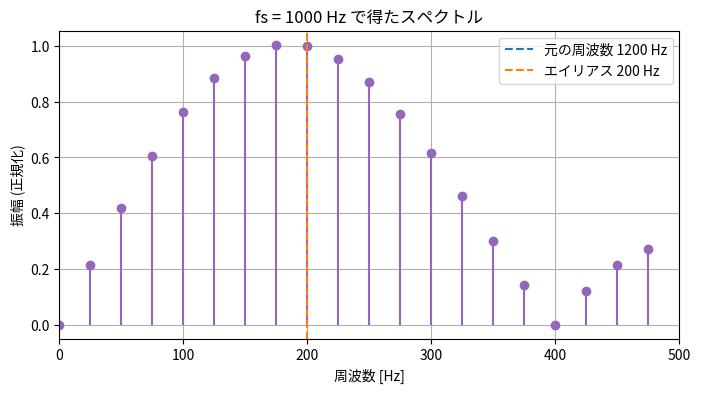

In [286]:
freqs_alias, mag_alias = compute_spectrum(x_sample, fs)
fig, ax = plt.subplots()
plot_discrete_spectrum(freqs_alias, mag_alias, fs, ax=ax, title='fs = 1000 Hz で得たスペクトル')
ax.axvline(f_signal, color='C0', linestyle='--', label=f'元の周波数 {f_signal} Hz')
ax.axvline(f_alias, color='C1', linestyle='--', label=f'エイリアス {f_alias:.0f} Hz')
ax.legend()
plt.show()


### 4 kHz でサンプリングした場合
十分なサンプリング周波数にすると、連続時間の 1200 Hz 成分がそのまま観測されます。


#### グラフ: 高サンプリング時の周波数スペクトル
4 kHz でサンプリングした場合のスペクトルを描画し、元の周波数ピークがそのまま再現されるケースを確認します。


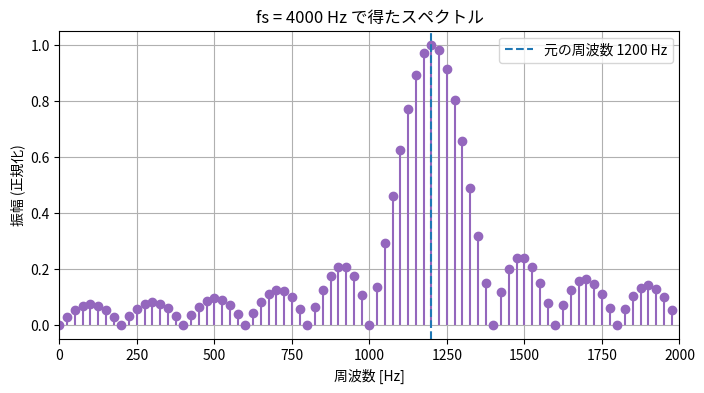

In [287]:
freqs_safe, mag_safe = compute_spectrum(x_sample_safe, fs_safe)
fig, ax = plt.subplots()
plot_discrete_spectrum(freqs_safe, mag_safe, fs_safe, ax=ax, title='fs = 4000 Hz で得たスペクトル')
ax.axvline(f_signal, color='C0', linestyle='--', label=f'元の周波数 {f_signal} Hz')
ax.legend()
plt.show()


時間領域と周波数領域の両方を観察することで、サンプル列がどの周波数に折り返して解釈されるかを定量的に捉えられます。
必要に応じて `zero_pad` や `f_signal` を変更し、分解能や折り返し位置の違いを試してみてください。


## 音声データによるエイリアシング

ここからは離散時間のサイン波だけでなく、実際の音声波形を用いてサンプリング不足による折り返しを確認します。
librosa のサンプル音源を使い、意図的にサンプリング周波数を下げた場合の波形・スペクトル・試聴結果を比較します。


#### 準備: 音声処理ライブラリの読み込み
librosa と IPython.display を追加で読み込み、波形表示や音声再生に備えます。


In [288]:
import librosa
import librosa.display
import IPython.display as ipd


#### ヘルパー: ブラウザ互換の音声プレイヤー
音声がグレイアウトして再生できない場合に備え、波形を 16-bit PCM に変換して HTML5 `<audio>` タグで埋め込む関数を用意します。


In [289]:
import io
import base64
import wave
from IPython.display import HTML, display

def render_audio(data, rate, description=''):
    data = np.asarray(data, dtype=np.float32)
    if data.size == 0:
        print('音声データが空です。')
        return
    max_val = np.max(np.abs(data))
    if max_val > 0:
        data = data / max(max_val, 1.0)
    pcm = (np.clip(data, -1.0, 1.0) * 32767).astype(np.int16)
    buffer = io.BytesIO()
    with wave.open(buffer, 'wb') as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(int(rate))
        wf.writeframes(pcm.tobytes())
    b64 = base64.b64encode(buffer.getvalue()).decode('ascii')
    label = f"<p>{description}</p>" if description else ""
    html = f"{label}<audio controls src=\'data:audio/wav;base64,{b64}\'></audio>"
    display(HTML(html))


#### グラフ: オリジナル音声の時間波形
librosa のデモ音源を 2 秒だけ読み込み、基準となる時間波形とサンプリング周波数を確認します。


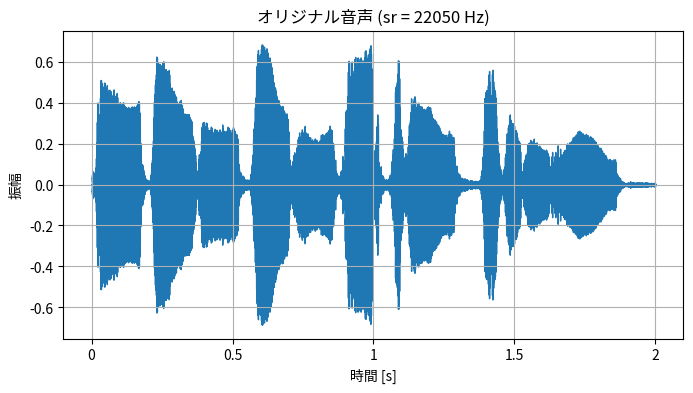

In [290]:
audio_path = librosa.ex('trumpet')
y_audio, sr_audio = librosa.load(audio_path, duration=2.0)

fig, ax = plt.subplots()
librosa.display.waveshow(y_audio, sr=sr_audio, ax=ax)
ax.set(title=f'オリジナル音声 (sr = {sr_audio} Hz)', xlabel='時間 [s]', ylabel='振幅')
plt.show()


#### 音声: オリジナル波形の試聴
元のサンプリング周波数のまま再生し、後で折り返した音と比較できるようにします。


In [291]:
render_audio(y_audio, sr_audio, description='オリジナル音声')


#### 概要: サンプリング周波数を意図的に下げる
以下では `target_fs_audio = 4000` Hz を目標にサンプルを間引き、ナイキスト周波数 (2 kHz) を下回る条件を作ります。
元波形に含まれる高周波が折り返して聞こえる様子を図と音声で確認します。


In [292]:
target_fs_audio = 4000
step_audio = max(2, int(np.round(sr_audio / target_fs_audio)))
fs_alias_audio = sr_audio / step_audio
y_alias = y_audio[::step_audio]

window_ms = 20
window_samples = int(sr_audio * window_ms / 1000)
alias_samples = max(1, int(window_samples / step_audio))
time_original = np.arange(window_samples) / sr_audio * 1e3
time_alias = np.arange(alias_samples) / fs_alias_audio * 1e3


#### グラフ: 低サンプリング時の時間波形比較
オリジナル波形 (青) と 4000 Hz 相当で間引いたサンプル列 (オレンジ) を 20 ms 区間で比較し、粗いサンプリングによって形状が失われる様子を示します。


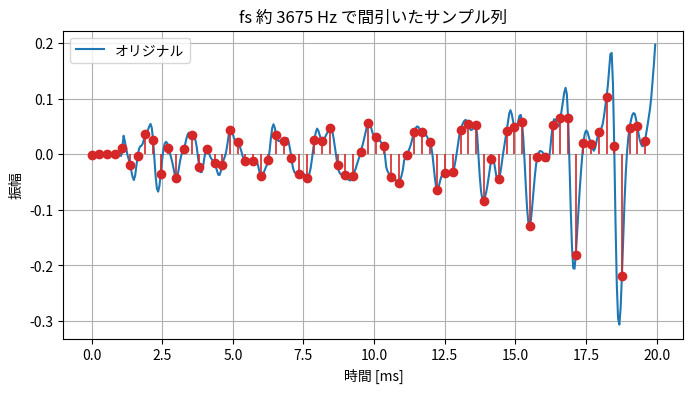

In [293]:
fig, ax = plt.subplots()
ax.plot(time_original, y_audio[:window_samples], label='オリジナル')
markerline, stemlines, baseline = ax.stem(time_alias, y_alias[:alias_samples], linefmt='C3-', markerfmt='C3o', basefmt=' ')
plt.setp(stemlines, linewidth=1.2)
ax.set(xlabel='時間 [ms]', ylabel='振幅', title=f'fs 約 {fs_alias_audio:.0f} Hz で間引いたサンプル列')
ax.legend()
plt.show()


#### 音声: 低サンプリング信号をそのまま再生
間引いた波形を実際のサンプリング周波数 (約 `fs_alias_audio` Hz) のまま再生し、帯域が狭まった音を確認します。


In [294]:

render_audio(y_alias, fs_alias_audio, description='低サンプリング (約 4 kHz) で取得した音声')

#### グラフ: スペクトル比較
最後に STFT を用いてオリジナル音声と折り返し後の音声のスペクトログラムを並べ、ナイキスト周波数より上の成分が低域へ写り込むことを確認します。


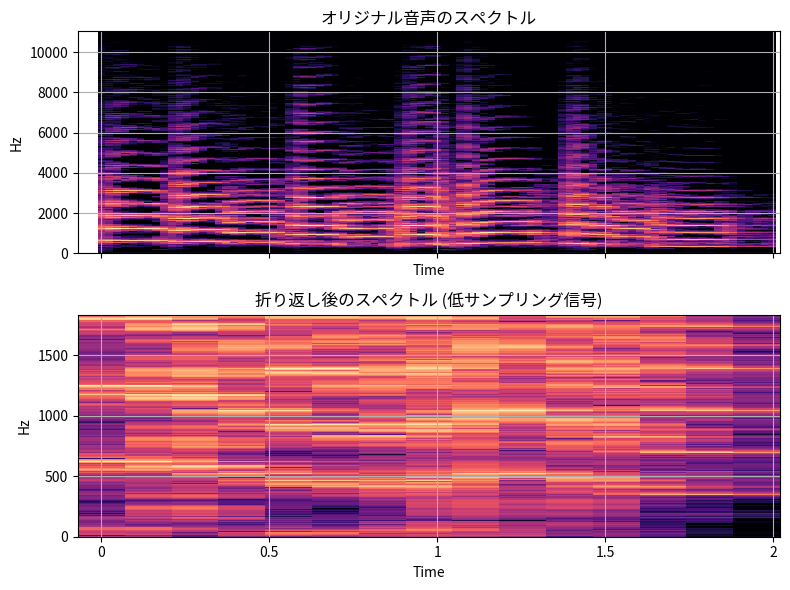

In [295]:
Y_spec = librosa.amplitude_to_db(np.abs(librosa.stft(y_audio)), ref=np.max)
Z_spec = librosa.amplitude_to_db(np.abs(librosa.stft(y_alias)), ref=np.max)

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
librosa.display.specshow(Y_spec, sr=sr_audio, x_axis='time', y_axis='linear', ax=ax[0])
ax[0].set(title='オリジナル音声のスペクトル')
librosa.display.specshow(Z_spec, sr=fs_alias_audio, x_axis='time', y_axis='linear', ax=ax[1])
ax[1].set(title='折り返し後のスペクトル (低サンプリング信号)')
plt.tight_layout()
plt.show()
